# Importing libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.cluster import BisectingKMeans
from scipy.stats import kendalltau, pearsonr, spearmanr

import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

import time

In [2]:
import warnings    
warnings.simplefilter('ignore', np.RankWarning) 

# Importing and formatting data

In [3]:
WDI_GFDI_df = pd.read_excel(r"cluster_analysis\WDI_GFDI_calculated.xlsx")

In [4]:
WDI_GFDI_df.dropna(subset=['Growth rate'
                           , 'Economy size'
                           , 'Deposits to GDP'
                           , 'Broad money'
                           , 'Credit to private'
                           , 'Value-traded'
                           , 'Turnover'
                           , 'MarCap to GDP'
                              ]
                      , inplace = True)

# Vizualizing the Years for which there is data for a country

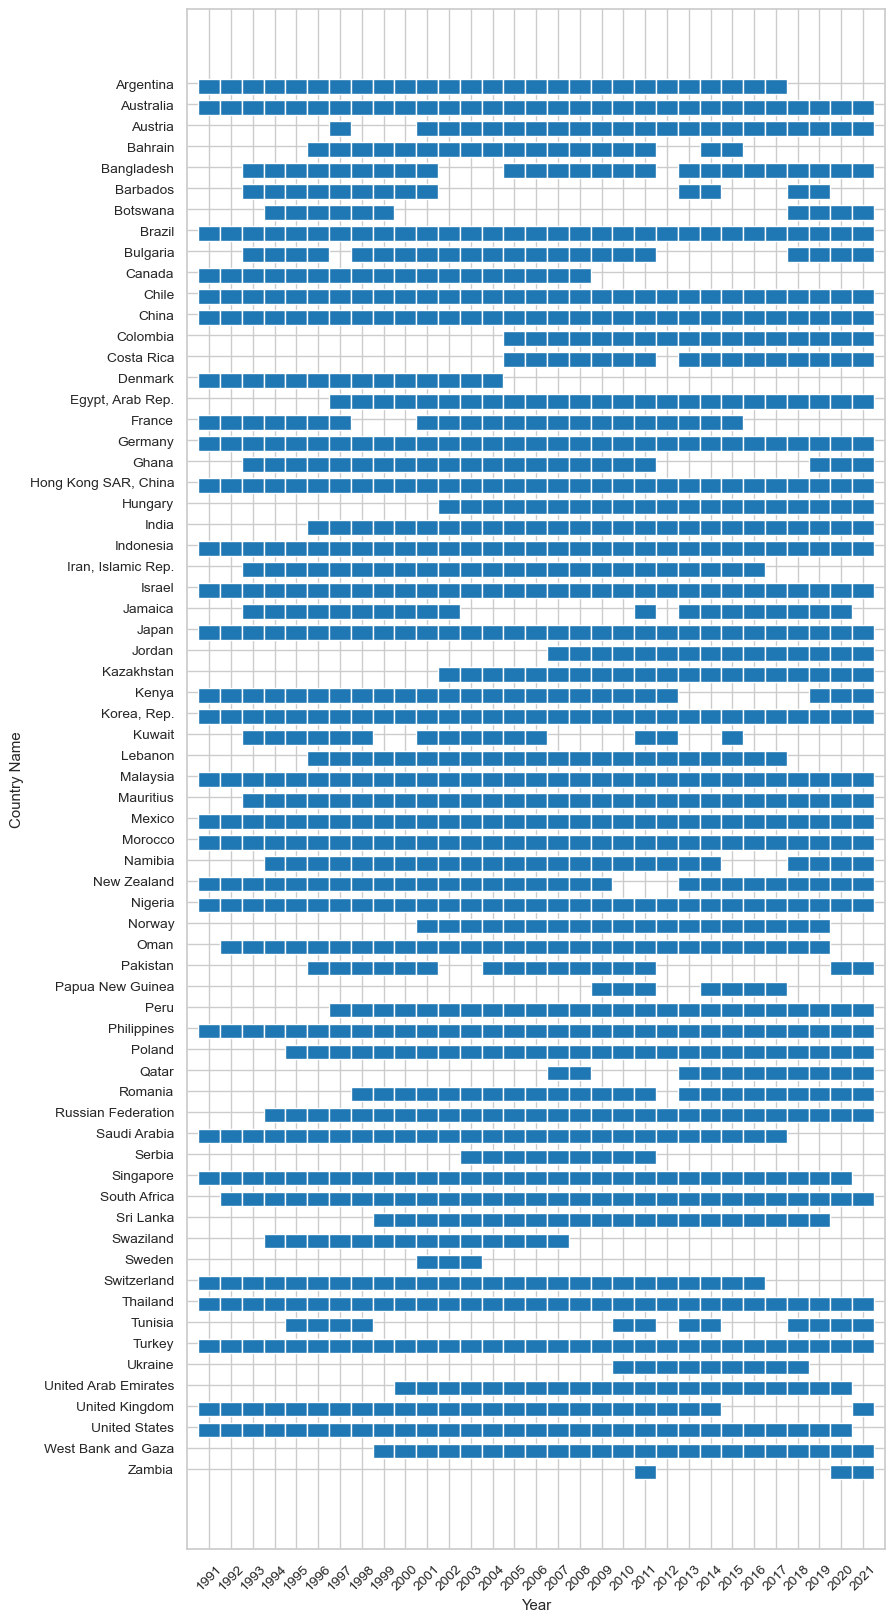

In [5]:
# Initialize figure and axis
sns.set_theme(style="whitegrid", palette=None, font_scale=0.9)
fig, ax = plt.subplots(figsize=(9, 20))

# plotting each year where countries are present
n = 0
for country in WDI_GFDI_df.sort_values(by=['Country Name'])['Country Name'].unique():
    time_line_df = WDI_GFDI_df[WDI_GFDI_df['Country Name'] == country][['Country Name', 'Year']]
    time_line_df['Year'] = time_line_df['Year']-0.5
    time_line_df['Length'] = 1
    n += 1
    ax.broken_barh(time_line_df[['Year', 'Length']].values.tolist(), (-1.2 + n, 0.7))

# Set y-ticks and labels
ax.set_yticks(range(len(WDI_GFDI_df.sort_values(by=['Country Name'])['Country Name'].unique())),
              labels=list(WDI_GFDI_df.sort_values(by=['Country Name'])['Country Name'].unique()))
ax.invert_yaxis()  # Invert y-axis for better visualization
ax.set_ylabel("Country Name")  # Label for the x-axis

# Set x-ticks and labels
min_year = min(WDI_GFDI_df.sort_values(by=['Year'])['Year'].unique())
max_year = max(WDI_GFDI_df.sort_values(by=['Year'])['Year'].unique())
ax.set_xticks(range(min_year, max_year+1))
ax.set_xlim(min_year-1,
            max_year+1
           )
plt.xticks(rotation=45)
ax.set_xlabel("Year")  # Label for the x-axis

# setting the title
# ax.set_title("Years for which there is data for a country")

# Display the graph
plt.show()

# cluster analysis

## prepping the df

In [6]:
financail_development_df = pd.DataFrame()
financail_development_clusters_df = pd.DataFrame()

# selecting the stock market activity indicators
wh1 = WDI_GFDI_df[['Growth rate'
                   , 'Economy size'
                   
                   , 'Broad money'
                   , 'Deposits to GDP'
                   , 'Credit to private'
                   
                   , 'MarCap to GDP'
                   , 'Value-traded'
                   , 'Turnover'
                  ]].dropna()

In [7]:
# z score standardization
z_score_df = (wh1 - wh1.mean())/wh1.std(ddof = 1)

## baseline cluster analysis

In [8]:
from sklearn.mixture import GaussianMixture

gm_bic= []
gm_aic= []
gm_score=[]
for i in range(2,26):
    gm = GaussianMixture(n_components=i
                         , covariance_type='spherical'
                         , tol=0.0001
                         , reg_covar=1e-06
                         , max_iter=1000
                         , n_init=1000
                         , init_params='k-means++'
                         , weights_init=None
                         , means_init=None
                         , precisions_init=None
                         , random_state=None
                         , warm_start=False
                         , verbose=0
                         , verbose_interval=10
                        ).fit(z_score_df)
    print("BIC for number of cluster(s) {}: {}".format(i,gm.bic(z_score_df)))
    # print("Log-likelihood score for number of cluster(s) {}: {}".format(i,gm.score(z_score_df)))
    print("-"*100)
    gm_bic.append(gm.bic(z_score_df))
    gm_aic.append(gm.aic(z_score_df))
    gm_score.append(gm.score(z_score_df))

BIC for number of cluster(s) 2: 26603.311581209775
----------------------------------------------------------------------------------------------------
BIC for number of cluster(s) 3: 23921.413650577437
----------------------------------------------------------------------------------------------------
BIC for number of cluster(s) 4: 22376.032405566486
----------------------------------------------------------------------------------------------------
BIC for number of cluster(s) 5: 21554.625763149346
----------------------------------------------------------------------------------------------------
BIC for number of cluster(s) 6: 20796.621819573404
----------------------------------------------------------------------------------------------------
BIC for number of cluster(s) 7: 20087.85360719684
----------------------------------------------------------------------------------------------------
BIC for number of cluster(s) 8: 19500.555282345085
--------------------------------------

In [9]:
gm_bic_df = pd.DataFrame((gm_bic - min(gm_bic))/(max(gm_bic) - min(gm_bic)), columns=['base_line'])
gm_aic_df = pd.DataFrame((gm_aic - min(gm_aic))/(max(gm_aic) - min(gm_aic)), columns=['base_line'])
gm_score_df = pd.DataFrame((gm_score - min(gm_score))/(max(gm_score) - min(gm_score)), columns=['base_line'])

In [10]:
gm_bic_df = gm_bic_df.reset_index(drop=False)
gm_bic_df['index'] = gm_bic_df['index']+2
gm_bic_df.rename(columns={'index':'number_of_clusters'
                          }
                , inplace = True)

gm_aic_df = gm_aic_df.reset_index(drop=False)
gm_aic_df['index'] = gm_aic_df['index']+2
gm_aic_df.rename(columns={'index':'number_of_clusters'
                          }
                , inplace = True)

gm_score_df = gm_score_df.reset_index(drop=False)
gm_score_df['index'] = gm_score_df['index']+2
gm_score_df.rename(columns={'index':'number_of_clusters'
                          }
                , inplace = True)

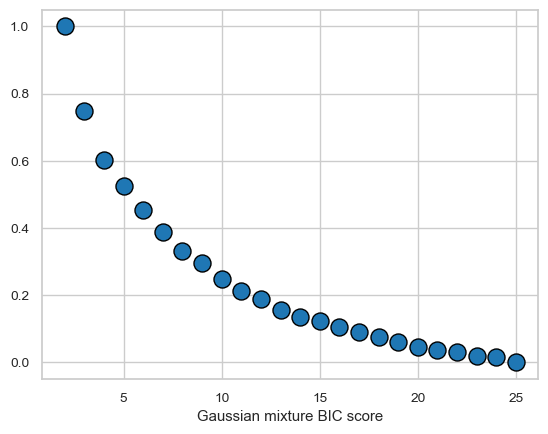

In [11]:
plt.scatter(x=gm_bic_df['number_of_clusters'],y=gm_bic_df['base_line'],s=150,edgecolor='k')
plt.grid(True)
plt.xlabel("Gaussian mixture BIC score")
plt.show()

## PCA

In [12]:
from sklearn.decomposition import PCA

pca_best = PCA(n_components='mle'
                  ,svd_solver='full'
                 )

pca_best.fit(z_score_df)

PCA(n_components='mle', svd_solver='full')

In [13]:
pd.DataFrame(data=pca_best.components_.T)

,0,1,2,3,4,5,6
0,-0.013355,0.247026,0.931278,-0.258738,0.013307,0.053830,0.024126
1,0.175191,0.629041,-0.194056,-0.188214,-0.641209,-0.261786,-0.082584
2,0.456316,-0.144387,0.003331,-0.320855,0.138990,-0.415357,-0.140027
3,0.440301,-0.267757,-0.013832,-0.289598,0.187530,-0.323628,0.156753
4,0.424061,0.069017,-0.164780,-0.383953,0.006368,0.798031,0.043628
5,0.405734,-0.242441,0.208428,0.461026,-0.266739,0.114522,-0.650056
6,0.431995,0.066268,0.124920,0.531731,-0.126745,0.001570,0.688364
7,0.189665,0.618717,-0.093060,0.260983,0.668531,-0.036634,-0.223827


In [14]:
PCA_loadings_df = pd.DataFrame(data=pca_best.components_.T, columns=['PC_'+str(i) for i in range(1,8)]).T

In [15]:
PCA_loadings_df.columns = z_score_df.columns

In [16]:
PCA_loadings_df

,Growth rate,Economy size,Broad money,Deposits to GDP,Credit to private,MarCap to GDP,Value-traded,Turnover
PC_1,-0.013355,0.175191,0.456316,0.440301,0.424061,0.405734,0.431995,0.189665
PC_2,0.247026,0.629041,-0.144387,-0.267757,0.069017,-0.242441,0.066268,0.618717
PC_3,0.931278,-0.194056,0.003331,-0.013832,-0.164780,0.208428,0.124920,-0.093060
PC_4,-0.258738,-0.188214,-0.320855,-0.289598,-0.383953,0.461026,0.531731,0.260983
PC_5,0.013307,-0.641209,0.138990,0.187530,0.006368,-0.266739,-0.126745,0.668531
PC_6,0.053830,-0.261786,-0.415357,-0.323628,0.798031,0.114522,0.001570,-0.036634
PC_7,0.024126,-0.082584,-0.140027,0.156753,0.043628,-0.650056,0.688364,-0.223827


In [17]:
PCA_loadings_df.to_excel(r"cluster_analysis\PCA_loadings_df.xlsx", index=False)

In [18]:
pca_explained_var = pca_best.explained_variance_ratio_
cum_explaiend_var = pca_explained_var.cumsum()
cum_explaiend_var = pd.DataFrame(pd.Series(data=cum_explaiend_var, index=PCA_loadings_df.index)).T
cum_explaiend_var.to_excel(r"cluster_analysis\cumulutive_explaiend_var.xlsx", index=False)

In [19]:
cum_explaiend_var

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7
0,0.496155,0.684396,0.808358,0.895133,0.956914,0.986267,0.99473


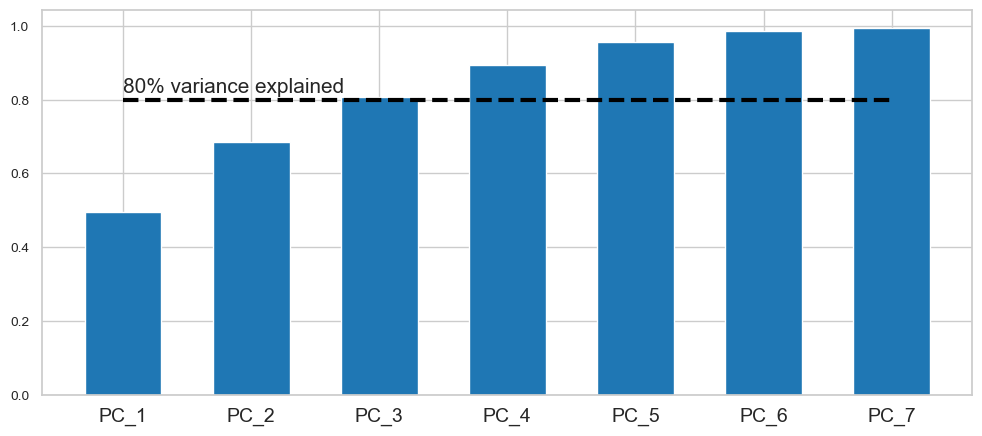

In [20]:
plt.figure(figsize=(12,5))
plt.bar(x=cum_explaiend_var.columns
        , height=cum_explaiend_var.iloc[0]
        , width=0.6
       )
plt.xticks(fontsize=14)
plt.hlines(y=0.8
           , xmin='PC_1'
           , xmax='PC_7'
           , linestyles='dashed'
           , lw=3,colors='black'
          )
plt.text(x='PC_1'
         , y=0.82
         , s="80% variance explained"
         , fontsize=15
        )
plt.show()

In [21]:
X_pca = pca_best.fit_transform(z_score_df)

In [22]:
pca_df=pd.DataFrame(data=X_pca,columns=['PC_'+str(i) for i in range(1,8)])

In [23]:
pca_df.to_excel(r"cluster_analysis\PCA_transformed_data.xlsx", index=False)

## finding the best number of PCs to use for clustering

In [24]:
for col in range(len(pca_df.columns)-1):
    # print(pca_df[pca_df.columns[:col+2]].columns[-1])
    # print(pca_df[pca_df.columns[:col+2]].head())
    
    gm_bic= []
    gm_aic= []
    gm_score=[]
    for i in range(2,26):
        gm = GaussianMixture(n_components=i
                             , covariance_type='spherical'
                             , tol=1e-3
                             , reg_covar=1e-06
                             , max_iter=1000
                             , n_init=1000
                             , init_params='k-means++'
                             , weights_init=None
                             , means_init=None
                             , precisions_init=None
                             , random_state=None
                             , warm_start=False
                             , verbose=0
                             , verbose_interval=10
                            ).fit(pca_df[pca_df.columns[:col+2]])
        print("BIC for number of cluster(s) {}: {}".format(i,gm.bic(pca_df[pca_df.columns[:col+2]])))
        print("AIC for number of cluster(s) {}: {}".format(i,gm.aic(pca_df[pca_df.columns[:col+2]])))
        print("Log-likelihood score for number of cluster(s) {}: {}".format(i,gm.score(pca_df[pca_df.columns[:col+2]])))
        print("-"*100)
        gm_bic.append(gm.bic(pca_df[pca_df.columns[:col+2]]))
        gm_aic.append(gm.aic(pca_df[pca_df.columns[:col+2]]))
        gm_score.append(gm.score(pca_df[pca_df.columns[:col+2]]))
    
    temp_gm_bic_df = pd.DataFrame((gm_bic - min(gm_bic))/(max(gm_bic) - min(gm_bic)), columns=[pca_df[pca_df.columns[:col+2]].columns[-1]])
    temp_gm_aic_df = pd.DataFrame((gm_aic - min(gm_aic))/(max(gm_aic) - min(gm_aic)), columns=[pca_df[pca_df.columns[:col+2]].columns[-1]])
    temp_gm_score_df = pd.DataFrame((gm_score - min(gm_score))/(max(gm_score) - min(gm_score)), columns=[pca_df[pca_df.columns[:col+2]].columns[-1]])

    gm_bic_df = pd.concat([gm_bic_df, temp_gm_bic_df], axis=1)
    gm_aic_df = pd.concat([gm_aic_df, temp_gm_aic_df], axis=1)
    gm_score_df = pd.concat([gm_score_df, temp_gm_score_df], axis=1)

BIC for number of cluster(s) 2: 9657.015297396187
AIC for number of cluster(s) 2: 9619.720833627236
Log-likelihood score for number of cluster(s) 2: -3.1556244525713653
----------------------------------------------------------------------------------------------------
BIC for number of cluster(s) 3: 8975.617492255291
AIC for number of cluster(s) 3: 8917.011906332653
Log-likelihood score for number of cluster(s) 3: -2.9221458299384535
----------------------------------------------------------------------------------------------------
BIC for number of cluster(s) 4: 8821.106401828214
AIC for number of cluster(s) 4: 8741.18969375189
Log-likelihood score for number of cluster(s) 4: -2.8617574552404372
----------------------------------------------------------------------------------------------------
BIC for number of cluster(s) 5: 8723.798296944547
AIC for number of cluster(s) 5: 8622.570466714536
Log-likelihood score for number of cluster(s) 5: -2.8201611257275085
----------------------

In [25]:
gm_bic_df.to_excel(r"cluster_analysis\cluster_analysis_bic_scores.xlsx", index=False)
gm_aic_df.to_excel(r"cluster_analysis\cluster_analysis_aic_scores.xlsx", index=False)
gm_score_df.to_excel(r"cluster_analysis\cluster_analysis_likelihood_scores.xlsx", index=False)

<Axes: xlabel='Number of clusters', ylabel='Normalized BIC scores'>

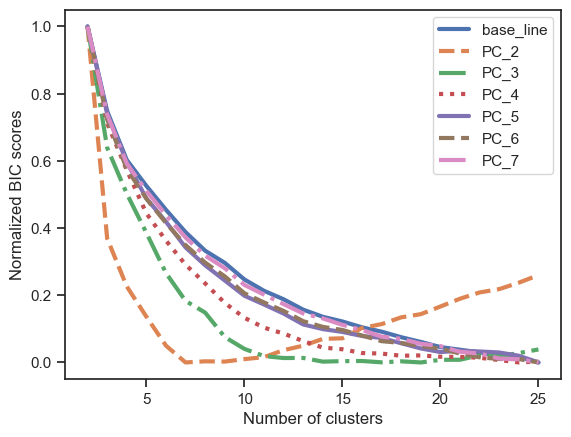

In [26]:
sns.set_theme(style="ticks", font_scale=1)

gm_bic_df.plot(x=gm_bic_df.columns[0]
               , y=gm_bic_df.columns[1:]
               , kind='line'
               , style=['-'
                        , '--'
                        , '-.'
                        , ':'
                        , '-'
                        , '--'
                        , '-.'
                        ]
               # , color=["#1a1a1a"
               #          , "#1a1a1a"
               #          , "#1a1a1a"
               #          , "#1a1a1a"
               #          , "#b3b3b3"
               #          , "#b3b3b3"
               #          , "#b3b3b3"
               #         ]  # All lines same color
               , linewidth=3
               # , title='Line Plots of Marks in Different Subjects'
               , ylabel = 'Normalized BIC scores'
               , xlabel = 'Number of clusters'
               # , fontsize = 'small'
              )

<Axes: xlabel='Number of clusters', ylabel='Normalized AIC scores'>

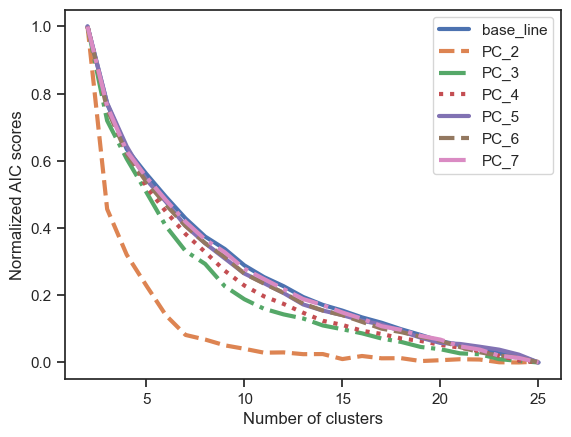

In [28]:
gm_aic_df.plot(x=gm_bic_df.columns[0]
               , y=gm_aic_df.columns[1:]
               , kind='line'
               , style=['-'
                        , '--'
                        , '-.'
                        , ':'
                        , '-'
                        , '--'
                        , '-.'
                        ]
               # , color=["#1a1a1a"
               #          , "#1a1a1a"
               #          , "#1a1a1a"
               #          , "#1a1a1a"
               #          , "#b3b3b3"
               #          , "#b3b3b3"
               #          , "#b3b3b3"
               #         ]  # All lines same color
               , linewidth=3
               # , title='Line Plots of Marks in Different Subjects'
               , ylabel = 'Normalized AIC scores'
               , xlabel = 'Number of clusters'
              )

<Axes: xlabel='Number of clusters', ylabel='Normalized log-likelihood scores'>

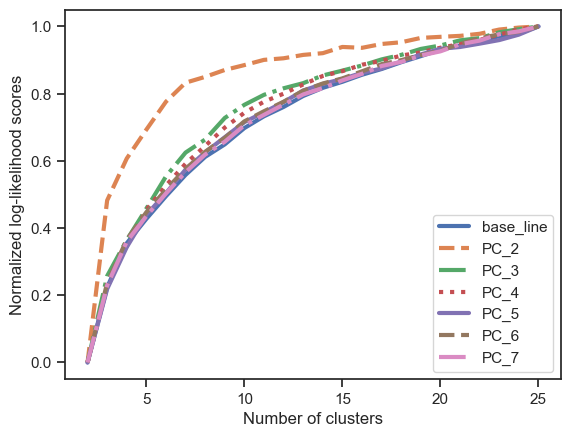

In [29]:
gm_score_df.plot(x=gm_bic_df.columns[0]
               , y=gm_score_df.columns[1:]
               , kind='line'
               , style=['-'
                        , '--'
                        , '-.'
                        , ':'
                        , '-'
                        , '--'
                        , '-.'
                        ]
               # , color=["#1a1a1a"
               #          , "#1a1a1a"
               #          , "#1a1a1a"
               #          , "#1a1a1a"
               #          , "#b3b3b3"
               #          , "#b3b3b3"
               #          , "#b3b3b3"
               #         ]  # All lines same color
               , linewidth=3
               # , title='Line Plots of Marks in Different Subjects'
               , ylabel = 'Normalized log-likelihood scores'
               , xlabel = 'Number of clusters'
              )

## conducting cluster analysis

In [30]:
# importing and setting up the clustering algorithm
from sklearn.mixture import GaussianMixture
clustering = GaussianMixture(n_components=7
                             , covariance_type='spherical'
                             , tol=0.0001
                             , reg_covar=1e-06
                             , max_iter=1000
                             , n_init=1000
                             , init_params='k-means++'
                             , weights_init=None
                             , means_init=None
                             , precisions_init=None
                             , random_state=None
                             , warm_start=False
                             , verbose=0
                             , verbose_interval=10
                            )

In [31]:
# clustering
clust = clustering.fit_predict(pca_df[pca_df.columns[:2]])

In [32]:
WDI_GFDI_df['Cluster index ID'] = clust

In [33]:
WDI_GFDI_df.to_excel(r"meta_analysis\data_with_clusters.xlsx", index=False)

In [34]:
WDI_GFDI_df

,Country Name,Country Code,Year,Growth rate,Economy size,Value-traded,Turnover,MarCap to GDP,Deposits to GDP,Broad money,Credit to private,Cluster index ID
9,United Arab Emirates,ARE,2000,3.631933,3.233207e+11,0.113095,2.059337,5.491800,30.52151,33.135689,31.278330,4
10,United Arab Emirates,ARE,2001,-4.864577,3.278442e+11,0.140352,2.512998,5.585043,38.45635,40.809199,34.415890,4
11,United Arab Emirates,ARE,2002,-3.604506,3.358222e+11,0.330552,1.779412,18.576494,40.09621,42.431937,36.115550,4
12,United Arab Emirates,ARE,2003,2.685563,3.653763e+11,0.778471,3.826087,20.346394,40.90881,43.160149,36.179490,4
13,United Arab Emirates,ARE,2004,3.715511,4.003298e+11,2.888563,7.693694,37.544554,42.85033,44.924063,37.723460,4
...,...,...,...,...,...,...,...,...,...,...,...,...
2068,South Africa,ZAF,2020,-7.678733,8.034681e+11,86.939111,27.943334,311.126474,63.21198,74.038826,109.054691,0
2069,South Africa,ZAF,2021,3.350531,8.432802e+11,61.292923,22.569825,271.570220,60.38076,69.994660,92.996973,3
2090,Zambia,ZMB,2011,2.116508,4.815934e+10,0.087385,0.643749,13.574321,16.65804,19.122024,13.692959,4
2099,Zambia,ZMB,2020,-5.567735,6.464176e+10,0.048187,0.321739,14.976983,26.49758,31.205962,15.163555,4
